# Navigare negli anime: trovare quello che fa per te in un catalogo sconfinato

Negli ultimi vent'anni, il numero di anime prodotti ogni anno è cresciuto in modo esponenziale. Oggi MyAnimeList cataloga quasi 29.000 titoli, un numero talmente alto da rendere impossibile anche solo sfogliarli tutti. Per un fan, questo non è necessariamente una buona notizia: più contenuto c'è, più diventa difficile trovare quello che vale davvero la pena guardare.

Il problema della scoperta è diventato centrale nell'esperienza del fandom moderno. Non mancano i consigli ma spesso si contraddicono, si sovrappongono, o puntano sempre agli stessi titoli.

MyAnimeList contiene 124 milioni di valutazioni distribuite su quasi 29.000 titoli. Questo notebook usa questi dati per costruire quattro strumenti di navigazione concreti.
- Da dove iniziare?
- La fonte conta: manga, light novel o storia originale?
- Dove cercare se hai già esaurito i titoli noti?
- Quando farlo, nel calendario delle uscite stagionali?

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

DATA_PATH = '../datasets_cleaned/'

details = pd.read_csv(DATA_PATH + 'details_clean.csv')
stats   = pd.read_csv(DATA_PATH + 'stats_clean.csv')

# Filtro: tipi con contenuto narrativo rilevante
# Special e TV Special inclusi: spesso adattano materiale originale e completano archi narrativi
TIPI = ['TV', 'Movie', 'OVA', 'ONA', 'Special', 'TV Special']
details = details[details['type'].isin(TIPI)].reset_index(drop=True)
stats   = stats[stats['mal_id'].isin(details['mal_id'])].reset_index(drop=True)

print('details:', details.shape)
print('stats:  ', stats.shape)
print('Tipi presenti:', sorted(details['type'].unique()))


details: (24131, 28)
stats:   (24131, 27)
Tipi presenti: ['Movie', 'ONA', 'OVA', 'Special', 'TV', 'TV Special']


## I punti di riferimento: dalla mappa dei generi alla Hall of Fame

Ogni navigazione parte da una visione d'insieme. Prima di scegliere un titolo specifico, vale la pena capire com'è fatto il territorio: quanti generi esistono, quanto sono grandi, quanto sono affidabili in termini di qualità media. Solo dopo aver capito la struttura del catalogo ha senso chiedersi: quali sono i titoli migliori al suo interno?

Il grafico che segue mappa tutti i generi su due assi: quanti anime esistono per quel genere (quanto è popolato il territorio) e qual è il loro punteggio medio (quanto è affidabile come zona di esplorazione). Un genere in alto a destra ha molti titoli di alta qualità: è un territorio ricco e consolidato. Un genere in alto a sinistra ha pochi titoli ma molto buoni: è una nicchia preziosa. Per chi vuole allargare la propria mappa, questo grafico mostra dove vale la pena guardare.

In [144]:
import plotly.express as px

det_g = details.dropna(subset=['genres', 'score']).copy()
det_g['genre'] = det_g['genres'].str[2:-2].str.split("', '")
det_g = det_g.explode('genre')
det_g = det_g[det_g['genre'].str.strip() != '']

genre_stats = (
    det_g.groupby('genre')
    .agg(n_titoli=('mal_id', 'count'), score_medio=('score', 'mean'))
    .query('n_titoli >= 30')
    .sort_values('score_medio', ascending=False)
    .reset_index()
)

score_mean = genre_stats['score_medio'].mean()

fig = px.scatter(
    genre_stats,
    x='n_titoli',
    y='score_medio',
    color='score_medio',
    color_continuous_scale='RdYlGn',
    hover_name='genre',
    hover_data={'n_titoli': True, 'score_medio': ':.2f'},
    labels={
        'n_titoli': 'Numero di titoli nel genere',
        'score_medio': 'Score medio MAL',
    },
    title='<b>La mappa dei generi: volume e qualità media per ogni territorio del catalogo</b>',
)

fig.update_traces(
    marker=dict(size=10, line=dict(color='white', width=1)),
)

# Offset custom per i generi sovrapposti, default per gli altri
custom_offsets = {
    'Girls Love':   dict(xshift=-30, yshift=12),
    'Boys Love':    dict(xshift=40,  yshift=12),
    'Gourmet':      dict(xshift=0,   yshift=-18),
    'Ecchi':        dict(xshift=-25, yshift=0),
    'Slice of Life':dict(xshift=40,  yshift=0),
    'Comedy':       dict(xshift=12,  yshift=-10),
}
default_offset = dict(xshift=12, yshift=9)

for _, row in genre_stats.iterrows():
    off = custom_offsets.get(row['genre'], default_offset)
    fig.add_annotation(
        x=row['n_titoli'],
        y=row['score_medio'],
        text=row['genre'],
        showarrow=False,
        font=dict(size=11),
        **off,
    )

fig.add_hline(
    y=score_mean,
    line_dash='dash',
    line_color='grey',
    opacity=0.5,
    annotation_text='score medio globale',
    annotation_position='top right',
    annotation_font_size=11,
    annotation_font_color='grey',
)

fig.update_layout(
    font_size=12,
    title_font_size=14,
    coloraxis_colorbar=dict(title='Score medio'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    height=600,
)

fig.show()


Una volta capita la struttura del territorio, la domanda naturale diventa: quali sono i titoli migliori al suo interno? Due criteri diversi danno risposte diverse.

- Il **punteggio medio** aggrega le valutazioni di migliaia di utenti: misura la qualità percepita dalla massa, ovvero quanti spettatori sono rimasti soddisfatti.
- I **favorites** misurano qualcosa di più viscerale: quante persone hanno deciso che quell'anime merita un posto speciale nel proprio profilo, al di là della valutazione numerica.

Le due classifiche che seguono confrontano i top 10 per punteggio e i top 10 per favorites.

In [145]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

top_score = (
    details
    .query('scored_by >= 10000')
    .nlargest(10, 'score')
    [['title', 'score', 'favorites', 'year']]
    .reset_index(drop=True)
)

top_fav = (
    details
    .nlargest(10, 'favorites')
    [['title', 'favorites', 'score']]
    .reset_index(drop=True)
)

in_both   = set(top_score['title']) & set(top_fav['title'])
n_overlap = len(in_both)

COLOR_BOTH = '#F4863E'  # arancione — appare in entrambe le classifiche
COLOR_SOLO = '#5B8DB8'  # blu — solo in questa classifica

def trunc(t, n=18):
    return t[:n] + '...' if len(t) > n else t

fav_titles_r   = top_fav['title'][::-1].tolist()
fav_values_r   = top_fav['favorites'][::-1].tolist()
score_titles_r = top_score['title'][::-1].tolist()
score_values_r = top_score['score'][::-1].tolist()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=[
        'Top 10 per Favorites',
        'Top 10 per Score',
    ],
    vertical_spacing=0.14,
)

fig.add_trace(go.Bar(
    y=[trunc(t) for t in fav_titles_r],
    x=fav_values_r,
    orientation='h',
    marker_color=[COLOR_BOTH if t in in_both else COLOR_SOLO for t in fav_titles_r],
    hovertext=fav_titles_r,
    hovertemplate='<b>%{hovertext}</b><br>Favorites: %{x:,}<extra></extra>',
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    y=[trunc(t) for t in score_titles_r],
    x=score_values_r,
    orientation='h',
    marker_color=[COLOR_BOTH if t in in_both else COLOR_SOLO for t in score_titles_r],
    hovertext=score_titles_r,
    hovertemplate='<b>%{hovertext}</b><br>Score: %{x:.2f}<extra></extra>',
    showlegend=False,
), row=2, col=1)

# Tracce vuote solo per la legenda
fig.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COLOR_BOTH, name='Appare in più classifiche',
))
fig.add_trace(go.Bar(
    x=[None], y=[None], orientation='h',
    marker_color=COLOR_SOLO, name='Solo in questa',
))

fig.update_layout(
    height=800,
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.08,
        xanchor='center', x=0.5,
        font_size=12,
    ),
    margin=dict(b=120),
)

fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0', zeroline=False)
fig.update_yaxes(showgrid=False, tickfont_size=11)

# Favorites: asse X parte da 0
fig.update_xaxes(title_text='Numero di Favorites', row=1, col=1)

# Score: asse X parte vicino al minimo per evidenziare le differenze
fig.update_xaxes(
    range=[top_score['score'].min() - 0.3, top_score['score'].max() + 0.15],
    title_text='Score MAL',
    row=2, col=1,
)

fig.show()


La mappa dei generi e la Hall of Fame insieme danno un primo orientamento completo: sappiamo quali territori esistono, qual è la qualità media di ciascuno, e quali titoli rappresentano il meglio in assoluto.

I titoli che compaiono sia nella classifica per punteggio che in quella per favorites sono pochi e questa divergenza è rilevante. Score e favorites misurano fenomeni distinti: il punteggio premia la coerenza qualitativa percepita dal pubblico mentre i favorites misurano l'attaccamento emotivo, quante persone hanno sentito quell'anime come qualcosa di proprio.

Sapere dove si trovano i punti di riferimento è però solo il primo passo. Il vero problema della navigazione emerge subito dopo: adesso che abbiamo visto i titoli al top, quali criteri usare per trovare il prossimo da guardare? Un punto di partenza concreto è la **fonte**: da dove nasce un anime ci dice qualcosa su cosa aspettarsi da esso.

## La fonte conta: da dove nascono gli anime che ami?

Ogni anime inizia come qualcosa d'altro: un manga letto su un treno, un light novel pubblicato su internet, un videogioco che ha venduto milioni di copie, oppure un'idea nata direttamente in uno studio di animazione senza nulla prima di essa.

La fonte non è un dettaglio tecnico — è una variabile che influenza struttura narrativa, ritmo, pubblico di riferimento e, spesso, la qualità del risultato finale. Un manga porta con sé anni di sviluppo dei personaggi già filtrati dal mercato; un light novel ha un pubblico fedele con aspettative precise; un originale non ha nessun termine di paragone, il che è sia un vantaggio che un rischio.

Il grafico che segue risponde a una domanda concreta: guardando la fonte di un anime, possiamo predire qualcosa sulla sua qualità?

In [146]:
# Aggregazione per fonte (min 30 titoli, solo anime con score)
source_agg = (
    details
    .dropna(subset=['source', 'score'])
    .groupby('source')
    .agg(
        n_titoli=('mal_id', 'count'),
        score_medio=('score', 'mean'),
        favorites_medio=('favorites', 'mean'),
    )
    .reset_index()
    .query('n_titoli >= 30')
    .sort_values('n_titoli', ascending=False)
    .reset_index(drop=True)
)

# Palette consistente per tutti i grafici di questa sezione
palette   = px.colors.qualitative.Alphabet[:len(source_agg)]
color_map = dict(zip(source_agg['source'], palette))

source_score = source_agg.sort_values('score_medio', ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    horizontal_spacing=0.22,
    subplot_titles=['Numero di titoli per fonte', 'Score medio MAL per fonte'],
)

fig.add_trace(go.Bar(
    y=source_agg['source'],
    x=source_agg['n_titoli'],
    orientation='h',
    marker_color=[color_map[s] for s in source_agg['source']],
    hovertemplate='<b>%{y}</b><br>Titoli: %{x:,}<extra></extra>',
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    y=source_score['source'],
    x=source_score['score_medio'].round(2),
    orientation='h',
    marker_color=[color_map[s] for s in source_score['source']],
    hovertemplate='<b>%{y}</b><br>Score medio: %{x:.2f}<extra></extra>',
    showlegend=False,
), row=1, col=2)

fig.update_layout(
    height=520,
    title=dict(
        text='<b>Da dove nascono gli anime: distribuzione e qualità media per fonte</b>',
        x=0.5, font_size=14,
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
)
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0', zeroline=False, title_text='Titoli', row=1, col=1)
fig.update_xaxes(
    showgrid=True, gridcolor='#f0f0f0', zeroline=False,
    range=[source_score['score_medio'].min() - 0.3, source_score['score_medio'].max() + 0.15],
    title_text='Score medio',
    row=1, col=2,
)
fig.update_yaxes(showgrid=False)
fig.show()

print(source_agg[['source', 'n_titoli', 'score_medio']].to_string(index=False))


      source  n_titoli  score_medio
       Manga      4818     6.832103
    Original      4265     6.150771
Visual novel      1144     6.307185
     Unknown      1110     5.891910
 Light novel      1058     6.930917
        Game       996     6.347902
       Novel       628     6.768471
       Other       606     6.036188
   Web manga       437     6.789588
4-koma manga       304     6.662599
   Web novel       151     7.225629
 Mixed media       126     6.559048
        Book       114     6.394912
Picture book        74     6.037973
   Card game        69     6.369855
       Music        42     6.172143


Il grafico a sinistra mostra subito una cosa: il **manga domina in modo schiacciante**. È la fonte di gran lunga più rappresentata nel catalogo — decenni di serializzazione su riviste come Weekly Shonen Jump hanno prodotto un bacino enorme di materiale adattabile. Gli anime "Original" — quelli nati direttamente in studio senza una fonte preesistente — sono numericamente la seconda categoria, ma distanti.

Il grafico a destra racconta però una storia diversa. **Il volume non correla con la qualità media**: le fonti con più titoli non sono necessariamente quelle con lo score più alto. Al contrario, fonti di nicchia come light novel, visual novel e novel tendono ad avere score medi più elevati — probabilmente perché vengono adattate solo quando il materiale di base ha già un pubblico fedele e aspettative alte.

Gli originali mostrano invece la varianza più alta: senza un termine di paragone preesistente, possono essere capolavori assoluti o delusioni complete. Il grafico che segue esplora questa varianza al livello del singolo anime.

In [147]:
det_src = (
    details
    .dropna(subset=['source', 'score', 'scored_by'])
    .query('scored_by >= 1000 and source in @source_agg.source.tolist()')
    .copy()
)

fig = px.scatter(
    det_src.sort_values('source'),
    x='scored_by', y='score',
    color='source', color_discrete_map=color_map,
    hover_name='title',
    hover_data={'source': True, 'scored_by': ':,', 'score': ':.2f', 'year': True, 'type': True},
    labels={
        'scored_by': 'Numero di valutazioni (scala log)',
        'score': 'Score MAL',
        'source': 'Fonte',
    },
    title='<b>Qualità e popolarità per fonte: ogni punto è un anime</b>',
    log_x=True, opacity=0.55,
)
fig.update_traces(marker=dict(size=5, line=dict(width=0.3, color='white')))
fig.update_layout(
    height=560,
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font_size=14,
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    legend=dict(title='Fonte', font_size=11),
)
fig.show()

La fonte rivela strutture che le classifiche tradizionali non vedono. Un manga di successo arriva al pubblico anime già testato da anni di serializzazione; un light novel adattato porta con sé un fandom di lettori con aspettative precise; un originale parte da zero, senza rete di sicurezza. Questa variabilità non è rumore — è un segnale utile per chi cerca il prossimo anime da guardare.

C'è però un limite: qualunque criterio si usi — fonte, genere, popolarità — si lavora sempre all'interno della mappa conosciuta. Il problema vero emerge quando si vuole uscire dal mainstream: quei titoli non compaiono nelle classifiche, non si accumulano nelle raccomandazioni, non salgono nelle heatmap di genere. Esistono, ma sono invisibili ai meccanismi normali di scoperta.

MAL li nasconde ma li contiene: il prossimo strumento di navigazione li porta alla luce.

---
## 3. Oltre la mappa conosciuta: i capolavori nascosti

Classifiche e fonte insieme disegnano una mappa densa nella zona dei titoli popolari — ma quella mappa ha bordi bianchi. Gran parte del catalogo anime è territorio inesplorato: titoli prodotti in nicchie, distribuiti in mercati limitati, usciti in anni in cui la comunità internazionale era più piccola, o semplicemente mai finiti nel flusso delle conversazioni mainstream.

MAL permette d'identificare questi titoli con precisione. Un anime con score ≥ 8.0 è — per definizione — considerato eccellente da chi lo ha visto: la media MAL si aggira intorno al 6.4, e superare l'8.0 richiede un consenso positivo significativo. La popolarità si misura con `scored_by` — quante persone hanno effettivamente valutato l'anime — che funziona indipendentemente dalla lunghezza della serie o dal suo stato (in corso o terminato). Un titolo con `scored_by` basso è davvero fuori dal radar, non semplicemente difficile da finire.

I criteri di selezione sono conservativi: score ≥ 8.0, scored_by tra 200 e 5.000. La soglia inferiore garantisce che il punteggio non sia il risultato di un campione troppo piccolo; quella superiore esclude i titoli già conosciuti dalla massa. Il risultato è una lista di destinazioni per chi ha già esaurito i percorsi più battuti.

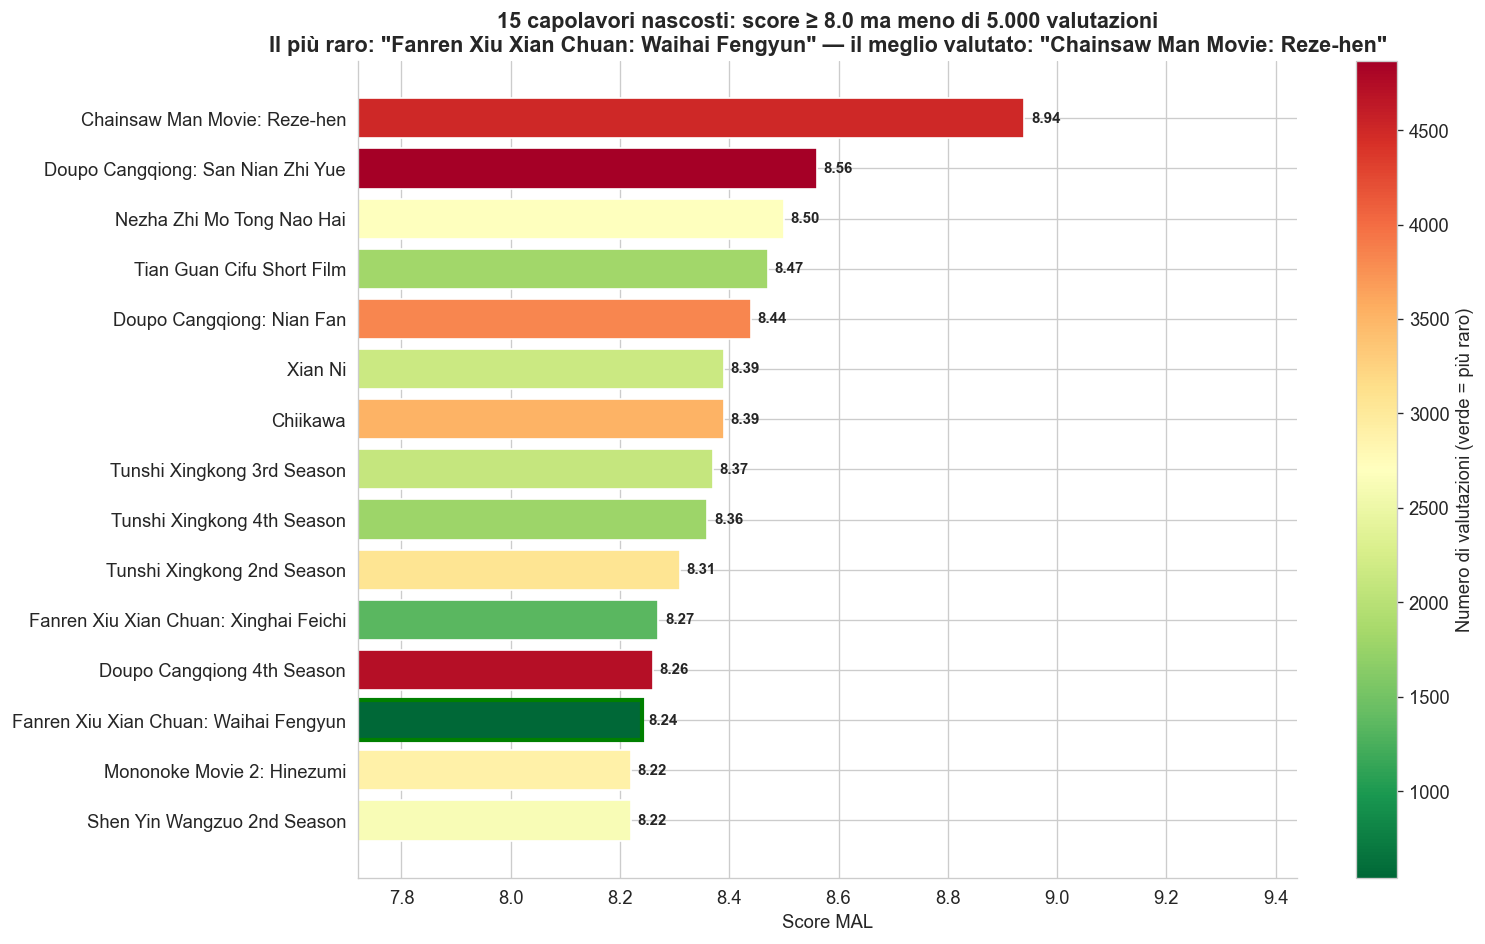

In [148]:
hidden = (
    details
    .query('score >= 8.0 and scored_by >= 200 and scored_by < 5000')
    .sort_values('score', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

norm   = plt.Normalize(hidden['scored_by'].min(), hidden['scored_by'].max())
colors = plt.cm.RdYlGn_r(norm(hidden['scored_by'].values[::-1]))

rarest  = hidden.loc[hidden['scored_by'].idxmin(), 'title']
best    = hidden.iloc[0]['title']
n_found = len(hidden)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(hidden['title'][::-1], hidden['score'][::-1], color=colors)
ax.bar_label(bars, fmt='%.2f', padding=4, fontweight='bold', fontsize=9)
ax.set_xlabel('Score MAL')
ax.set_xlim(hidden['score'].min() - 0.5, hidden['score'].max() + 0.5)
ax.set_title(
    f'{n_found} capolavori nascosti: score ≥ 8.0 ma meno di 5.000 valutazioni\n'
    f'Il più raro: "{rarest}" — il meglio valutato: "{best}"',
    fontsize=13, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)

rarest_idx = list(hidden['title'][::-1]).index(rarest)
bars[rarest_idx].set_edgecolor('green')
bars[rarest_idx].set_linewidth(2.5)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Numero di valutazioni (verde = più raro)')
plt.tight_layout()
plt.show()

La lista che emerge è una mappa del tesoro per chi vuole navigare oltre il mainstream. Ogni titolo rappresenta un'opera che ha convinto quasi chiunque l'abbia vista — ma che pochissime persone hanno ancora trovato. Il titolo con il minor numero di valutazioni, evidenziato in verde, è la destinazione più remota: il capolavoro più nascosto dell'intero dataset.

Usare `scored_by` invece dei completamenti risolve un problema strutturale importante: serie lunghe ancora in corso come One Piece o Naruto hanno pochissimi "completamenti" semplicemente perché finirle richiede anni — non perché siano sconosciute. `scored_by` cattura invece chiunque abbia guardato abbastanza episodi da esprimere una valutazione, indipendentemente dal formato o dalla lunghezza. Chi appare in questa lista è davvero fuori dal radar.

Finora abbiamo navigato il catalogo esistente — titoli già usciti, già valutati, già connessi. Ma ogni stagione il catalogo si espande: nuovi anime escono ogni tre mesi, e alcuni di essi potrebbero essere le prossime hidden gems prima ancora che qualcuno le scopra. Per intercettarli, serve capire la struttura temporale delle uscite.

---
## 4. Navigare nel tempo: il calendario stagionale delle uscite

Il catalogo anime non è statico: si rinnova ogni tre mesi, seguendo il ritmo delle stagioni giapponesi — Winter, Spring, Summer, Fall. Per un fan che vuole stare al passo, o che vuole intercettare un titolo prima che diventi popolare (e magari scoprire la prossima hidden gem in tempo reale), capire la struttura del calendario è uno strumento di navigazione essenziale.

La domanda è: la distribuzione dei generi tra le stagioni è casuale, o le case di produzione seguono una logica precisa? Se esistono pattern stabili — certi generi che si concentrano in certe stagioni — allora il calendario diventa prevedibile, e un fan può calibrare le aspettative stagione per stagione invece di scoprirlo ogni volta.

La heatmap che segue mostra, per ciascuna combinazione stagione/genere, quanti anime sono stati rilasciati storicamente. I rettangoli blu evidenziano la stagione dominante per i tre generi più prodotti in assoluto.

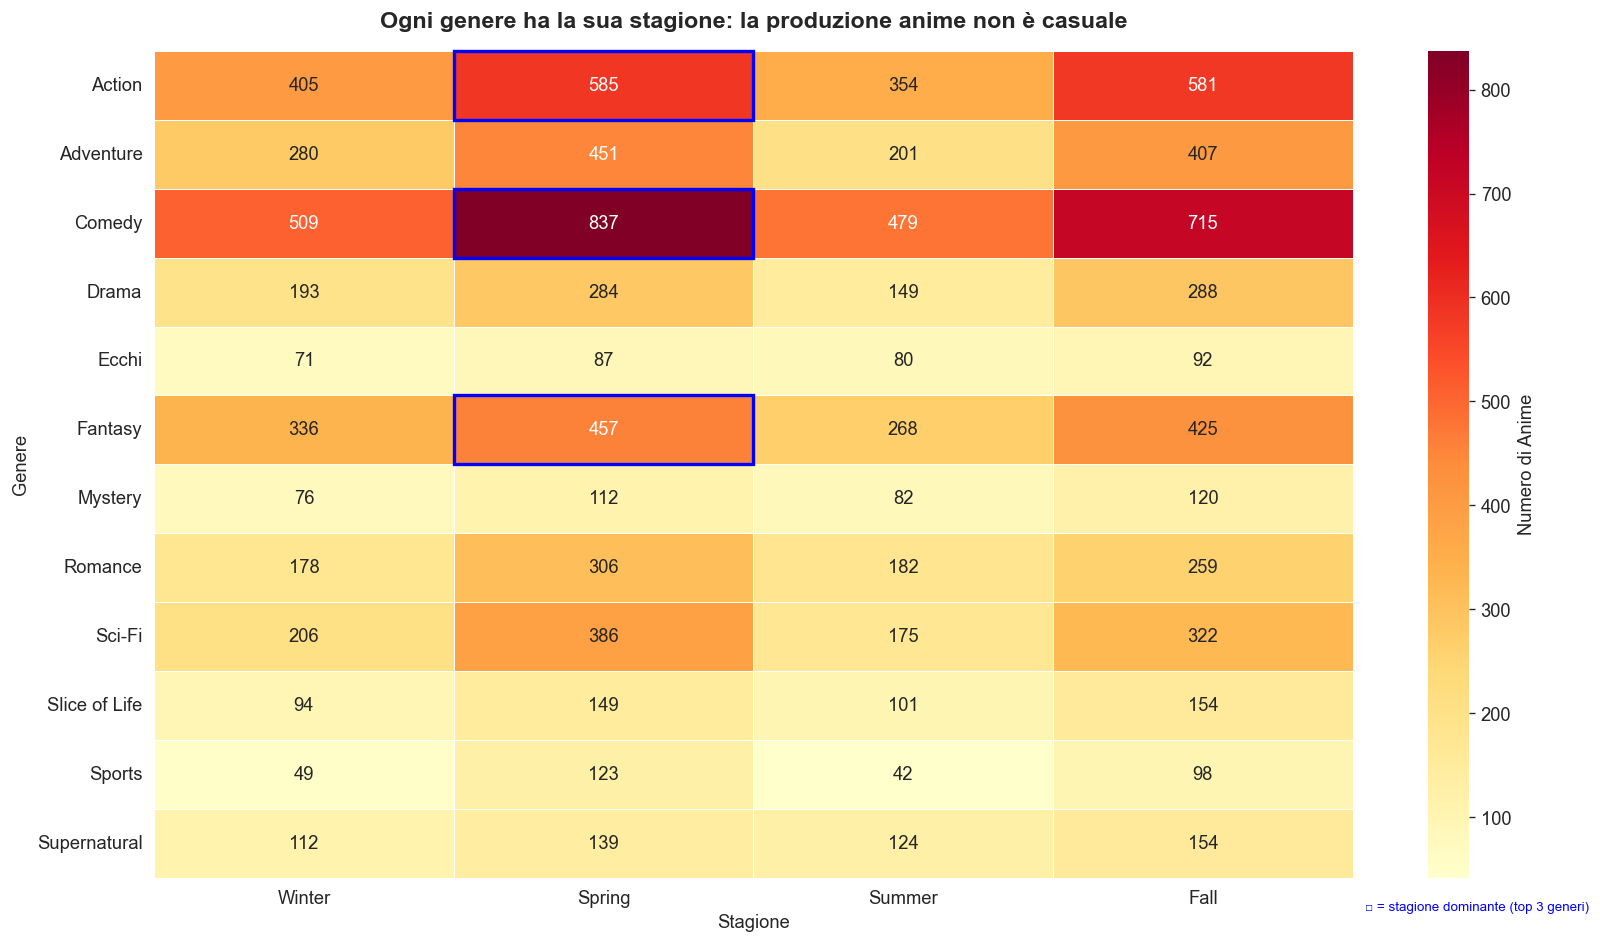

In [149]:
det_genres = details.dropna(subset=['season', 'genres']).copy()
det_genres['genre'] = det_genres['genres'].str[2:-2].str.split("', '")
det_genres = det_genres.explode('genre')
det_genres = det_genres[det_genres['genre'].str.strip() != '']

top_genres   = det_genres['genre'].value_counts().head(12).index
season_order = ['winter', 'spring', 'summer', 'fall']

pivot = (
    det_genres
    .query('genre in @top_genres')
    .groupby(['season', 'genre'])
    .size()
    .unstack(fill_value=0)
    .reindex([s for s in season_order if s in det_genres['season'].unique()])
)
pivot.index = pivot.index.str.capitalize()

# Stagione dominante per ogni genere
dominant_season = pivot.idxmax(axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot.T, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Numero di Anime'}
)
ax.set_title('Ogni genere ha la sua stagione: la produzione anime non è casuale',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Stagione')
ax.set_ylabel('Genere')

# Annota la stagione dominante per i top 3 generi
for genre in list(top_genres)[:3]:
    if genre in pivot.columns:
        row_idx = list(pivot.T.index).index(genre)
        col_idx = list(pivot.index).index(dominant_season[genre])
        ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1,
                     fill=False, edgecolor='blue', lw=2, clip_on=False))

ax.text(1.01, -0.04, '□ = stagione dominante (top 3 generi)',
        transform=ax.transAxes, fontsize=8, color='blue', ha='left')

plt.tight_layout()
plt.show()


---
## Conclusione: quattro strumenti per orientarsi

Il problema del fandom moderno non è la mancanza di contenuto — è l'eccesso. Con quasi 29.000 titoli catalogati e centinaia di nuove uscite ogni anno, la sfida non è trovare anime da guardare: è trovare *quello giusto per te*, nel momento giusto.

Questo notebook ha proposto quattro strumenti di navigazione complementari, ciascuno utile in una fase diversa del percorso.

La **Hall of Fame** offre i punti di riferimento iniziali: i landmark del catalogo, differenziati tra qualità media e attaccamento emotivo. La **fonte** aggiunge un livello di lettura strutturale: sapere da dove nasce un anime permette di calibrare le aspettative prima ancora di iniziare a guardarlo. Le **hidden gems** aprono il territorio inesplorato: capolavori che le classifiche non raggiungono, ma che i dati di MAL permettono d'identificare con precisione. Il **calendario stagionale**, infine, porta la navigazione nel tempo: capire quando e dove si concentrano certi generi significa sapere quando tenere gli occhi aperti per le prossime scoperte.

Nessuno di questi strumenti funziona da solo — è usandoli insieme che si costruisce un percorso di scoperta che va dai titoli universalmente riconosciuti fino alle opere che quasi nessuno ha ancora trovato.

| Strumento di navigazione | A cosa serve |
|---|---|
| Hall of Fame | Trovare i punti di riferimento — i landmark del catalogo |
| Fonte | Leggere la struttura — da dove nasce un anime dice qualcosa su cosa aspettarsi |
| Hidden Gems | Esplorare oltre il mainstream — capolavori fuori dai radar |
| Calendario stagionale | Navigare nel tempo — sapere quando cercare cosa |

---
## Conclusione: quattro strumenti per orientarsi

Il problema del fandom moderno non è la mancanza di contenuto — è l'eccesso. Con quasi 29.000 titoli catalogati e centinaia di nuove uscite ogni anno, la sfida non è trovare anime da guardare: è trovare *quello giusto per te*, nel momento giusto.

Questo notebook ha proposto quattro strumenti di navigazione complementari, ciascuno utile in una fase diversa del percorso.

La **Hall of Fame** offre i punti di riferimento iniziali: i landmark del catalogo, differenziati tra qualità media e attaccamento emotivo. Le **raccomandazioni del fandom** costruiscono i percorsi tra quei landmark: conoscendo un titolo che ami, puoi muoverti verso ciò che gli assomiglia seguendo il consenso collettivo di chi ha già percorso quel tratto. Le **hidden gems** aprono il territorio inesplorato: capolavori che le classifiche e le raccomandazioni non raggiungono, ma che i dati di MAL permettono d'identificare con precisione. Il **calendario stagionale**, infine, porta la navigazione nel tempo: capire quando e dove si concentrano certi generi significa sapere quando tenere gli occhi aperti per le prossime scoperte.

Nessuno di questi strumenti funziona da solo — è usandoli insieme che si costruisce un percorso di scoperta che va dai titoli universalmente riconosciuti fino alle opere che quasi nessuno ha ancora trovato.

| Strumento di navigazione | A cosa serve |
|---|---|
| Hall of Fame | Trovare i punti di riferimento — i landmark del catalogo |
| Raccomandazioni | Muoversi per connessioni — "ho amato X, cosa guardo dopo?" |
| Hidden Gems | Esplorare oltre il mainstream — capolavori fuori dai radar |
| Calendario stagionale | Navigare nel tempo — sapere quando cercare cosa |